In [1]:
# ========== Install Required Packages ==========
!pip install gensim gradio contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# Import All Required Libraries
# ============================================================
# Imports all necessary libraries for the project.
# - Data Handling: pandas, numpy
# - Text Processing: re, nltk, contractions
# - Visualization: matplotlib, seaborn, wordcloud
# - Deep Learning: tensorflow.keras
# - Model Evaluation: sklearn
# - Pre-trained Embeddings: gensim.downloader
# - GUI: gradio
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import contractions
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import Zeros
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import gensim.downloader as api
import gradio as gr

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [3]:
# ============================================================
# Load and Explore the Dataset
# ============================================================
# Loads the sarcasm detection dataset and displays
# basic information about its structure and content.
# ============================================================

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/AI/Assesment/Part 3/Dataset/sarcastic_headlines.csv')

# Display basic information about the dataset
print("=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nDataset Info:")
df.info()

DATASET LOADED SUCCESSFULLY

Dataset Shape: (28619, 2)

Columns: ['headline', 'is_sarcastic']

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


Class Distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Class Distribution (%):
is_sarcastic
0    52.36032
1    47.63968
Name: proportion, dtype: float64


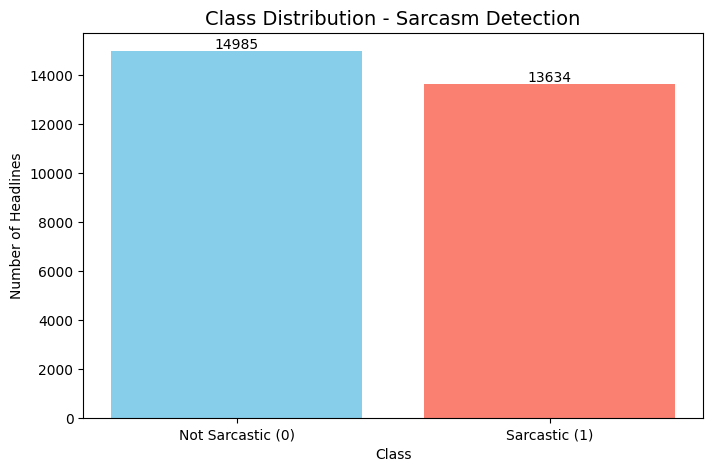


Null Values:
headline        0
is_sarcastic    0
dtype: int64

Headline Length Statistics:
count    28619.000000
mean        62.308571
std         20.726483
min          7.000000
25%         49.000000
50%         62.000000
75%         75.000000
max        926.000000
Name: headline_length, dtype: float64


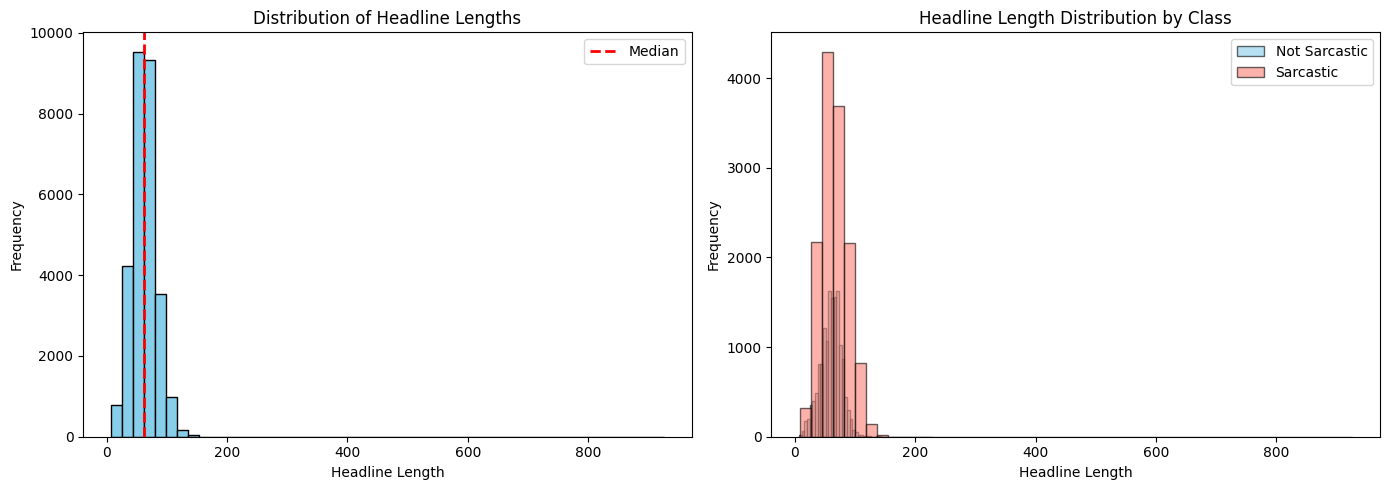


--- Example: NOT SARCASTIC Headlines ---
  • dem rep. totally nails why congress is falling short on gender, racial equality
  • eat your veggies: 9 deliciously different recipes
  • my white inheritance
  • 5 ways to file your taxes with less stress
  • lots of parents know this scenario

--- Example: SARCASTIC Headlines ---
  • thirtysomething scientists unveil doomsday clock of hair loss
  • inclement weather prevents liar from getting to work
  • mother comes pretty close to using word 'streaming' correctly
  • richard branson's global-warming donation nearly as much as cost of failed balloon trips
  • shadow government getting too large to meet in marriott conference room b


In [4]:
# ============================================================
# Exploratory Data Analysis (EDA)
# ============================================================
# Perform exploratory data analysis to understand
# the dataset's characteristics:
# - Class balance/distribution
# - Headline length statistics
# - Length distribution by class
# - Sample headlines from each class
# ============================================================

# --- Class Distribution ---
print("Class Distribution:")
print(df['is_sarcastic'].value_counts())
print("\nClass Distribution (%):")
print(df['is_sarcastic'].value_counts(normalize=True) * 100)

# Visualize class distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(['Not Sarcastic (0)', 'Sarcastic (1)'],
               df['is_sarcastic'].value_counts().values,
               color=['skyblue', 'salmon'])
plt.title('Class Distribution - Sarcasm Detection', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Number of Headlines')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')
plt.show()

# Check for null values
print("\nNull Values:")
print(df.isnull().sum())

# --- Headline Length Analysis ---
df['headline_length'] = df['headline'].astype(str).apply(len)
print("\nHeadline Length Statistics:")
print(df['headline_length'].describe())

# Plot headline length distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(df['headline_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(df['headline_length'].median(), color='red', linestyle='dashed',
                linewidth=2, label='Median')
axes[0].set_title('Distribution of Headline Lengths')
axes[0].set_xlabel('Headline Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Distribution by class
for label, color, name in [(0, 'skyblue', 'Not Sarcastic'), (1, 'salmon', 'Sarcastic')]:
    subset = df[df['is_sarcastic'] == label]['headline_length']
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, edgecolor='black')
axes[1].set_title('Headline Length Distribution by Class')
axes[1].set_xlabel('Headline Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Display sample headlines from each class
print("\n--- Example: NOT SARCASTIC Headlines ---")
for text in df[df['is_sarcastic'] == 0]['headline'].head(5):
    print(f"  • {text}")

print("\n--- Example: SARCASTIC Headlines ---")
for text in df[df['is_sarcastic'] == 1]['headline'].head(5):
    print(f"  • {text}")

In [5]:
# ============================================================
# Text Preprocessing Function
# ============================================================
# Define a comprehensive text cleaning function
# that performs the following steps:
# 1. Lowercase conversion
# 2. URL, mention, hashtag, and number removal
# 3. Special character removal
# 4. Contraction expansion
# 5. Stopword removal and lemmatization
# ============================================================

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean and preprocess a headline text for sarcasm detection.
    Args:
        text (str): Raw headline text.
    Returns:
        str: Cleaned and lemmatized text.
    """
    text = str(text)

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtag symbol only (keep the text)
    text = re.sub(r'#', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 7. Expand contractions (e.g., "don't" -> "do not")
    text = contractions.fix(text)

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize, remove stopwords, and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 10. Join back into a single string
    return ' '.join(words)

# --- Test the cleaning function ---
sample_texts = [
    "I just LOVE waiting in traffic!!! #blessed",
    "thirtysomething scientists unveil doomsday clock of hair loss",
    "5 ways to file your taxes with less stress"
]

for original in sample_texts:
    print(f"Original : {original}")
    print(f"Cleaned  : {clean_text(original)}")
    print()

Original : I just LOVE waiting in traffic!!! #blessed
Cleaned  : love waiting traffic blessed

Original : thirtysomething scientists unveil doomsday clock of hair loss
Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

Original : 5 ways to file your taxes with less stress
Cleaned  : way file tax less stress



In [6]:
# ============================================================
# Apply Preprocessing to the Dataset
# ============================================================
# Apply the clean_text function to the entire
# dataset, remove any headlines that become empty after
# cleaning, and display before/after examples.
# ============================================================

print("Cleaning headlines...")
print(f"Samples before cleaning: {len(df)}")

# Apply the cleaning function to all headlines
df['cleaned_headline'] = df['headline'].apply(clean_text)

# Remove headlines that became empty after cleaning
empty_mask = df['cleaned_headline'] == ''
print(f"Empty headlines after cleaning: {empty_mask.sum()}")
if empty_mask.sum() > 0:
    df = df[~empty_mask]

print(f"Samples after cleaning: {len(df)}")

# Display before-and-after comparison for first 8 samples
print("\n--- Before vs After Cleaning ---")
comparison = df[['headline', 'cleaned_headline', 'is_sarcastic']].head(8)
for idx, row in comparison.iterrows():
    print(f"\n[{row['is_sarcastic']}] Original: {row['headline'][:100]}")
    print(f"    Cleaned:  {row['cleaned_headline'][:100]}")

Cleaning headlines...
Samples before cleaning: 28619
Empty headlines after cleaning: 2
Samples after cleaning: 28617

--- Before vs After Cleaning ---

[1] Original: thirtysomething scientists unveil doomsday clock of hair loss
    Cleaned:  thirtysomething scientist unveil doomsday clock hair loss

[0] Original: dem rep. totally nails why congress is falling short on gender, racial equality
    Cleaned:  dem rep totally nail congress falling short gender racial equality

[0] Original: eat your veggies: 9 deliciously different recipes
    Cleaned:  eat veggie deliciously different recipe

[1] Original: inclement weather prevents liar from getting to work
    Cleaned:  inclement weather prevents liar getting work

[1] Original: mother comes pretty close to using word 'streaming' correctly
    Cleaned:  mother come pretty close using word streaming correctly

[0] Original: my white inheritance
    Cleaned:  white inheritance

[0] Original: 5 ways to file your taxes with less stress
    C

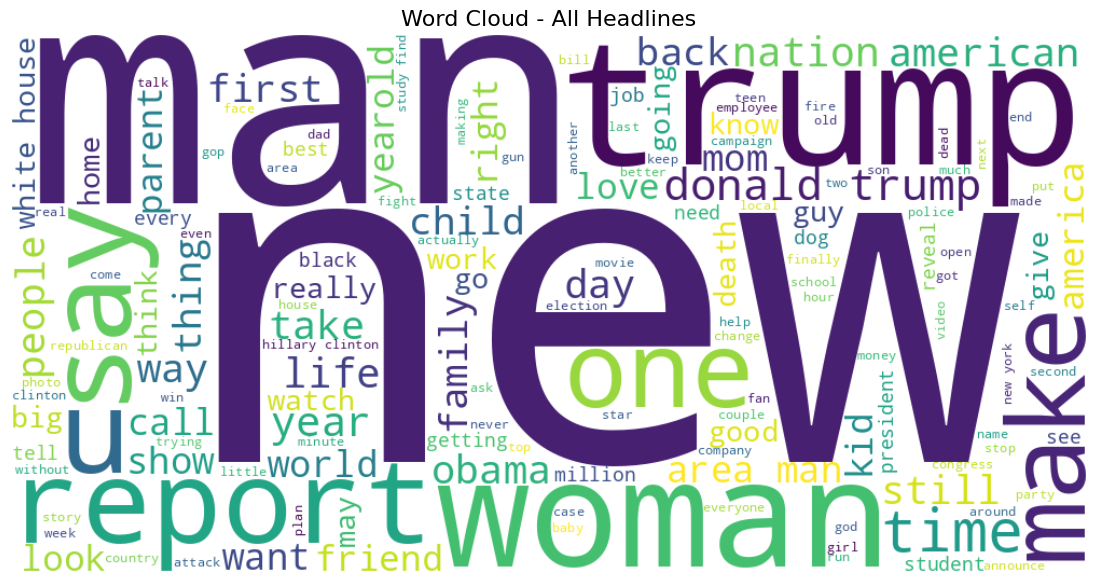

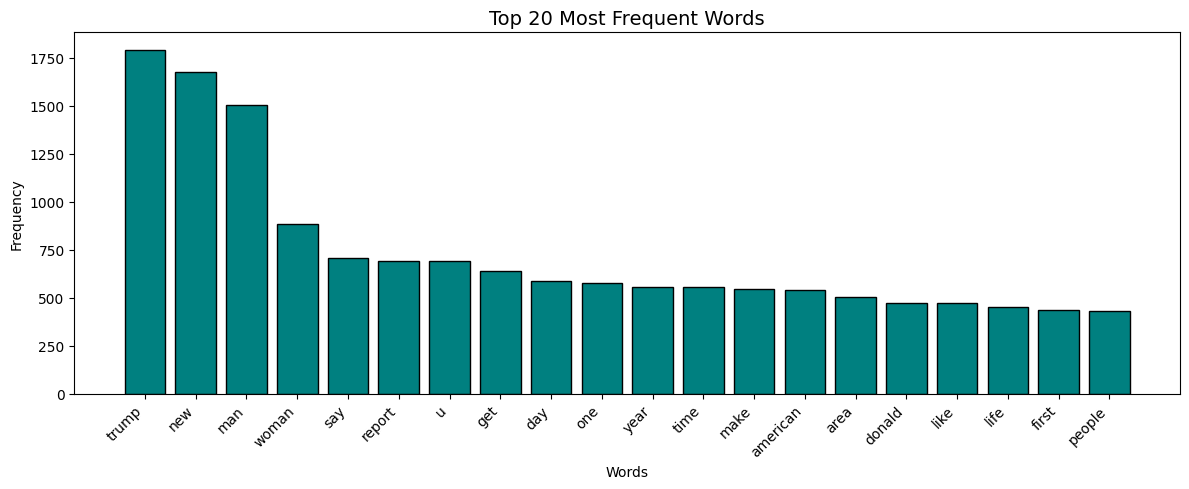

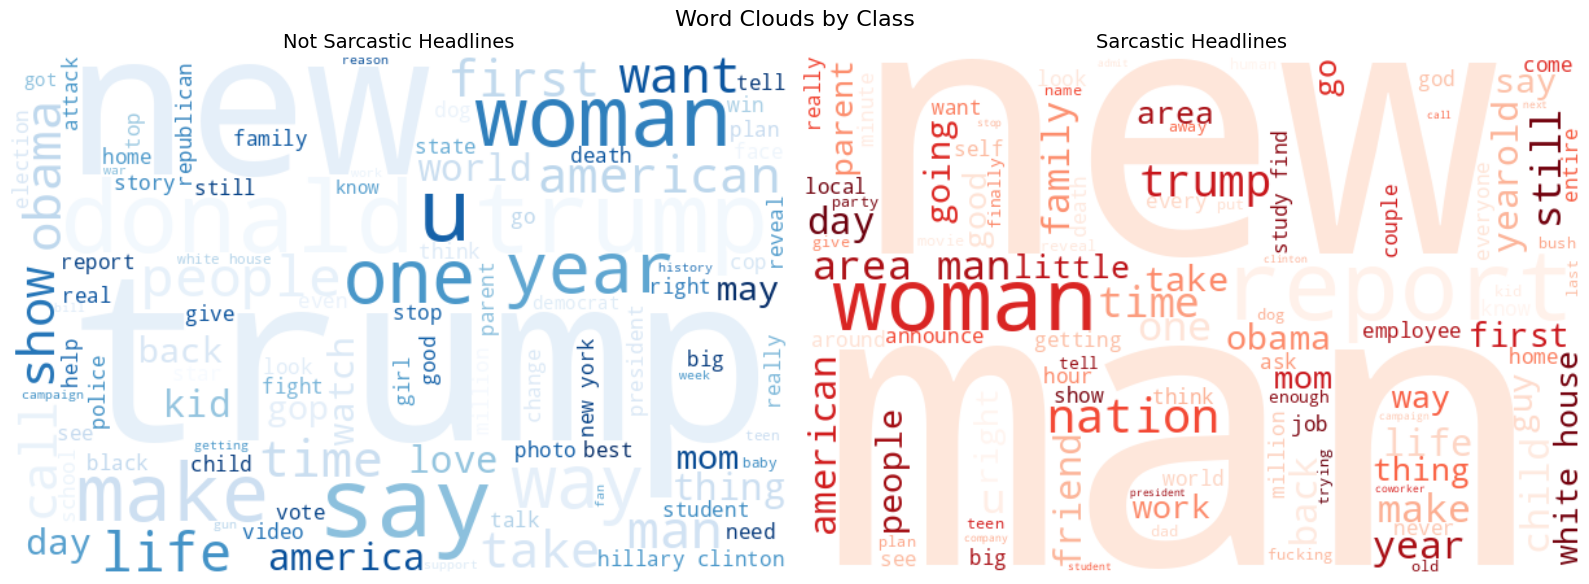

In [7]:
# ============================================================
# Visualize Cleaned Data
# ============================================================
# Create visualizations to explore the cleaned
# text data:
# 1. Overall word cloud
# 2. Top 20 most frequent words bar chart
# 3. Class-specific word clouds (Sarcastic vs. Not Sarcastic)
# ============================================================

# --- Overall Word Cloud ---
all_words = ' '.join(df['cleaned_headline'])
plt.figure(figsize=(14, 7))
wordcloud = WordCloud(width=1000, height=500,
                      background_color='white',
                      max_words=150,
                      colormap='viridis',
                      random_state=42).generate(all_words)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Headlines', fontsize=16)
plt.show()

# --- Top 20 Most Frequent Words ---
from collections import Counter
word_freq = Counter(all_words.split())
top_words = word_freq.most_common(20)

plt.figure(figsize=(12, 5))
words, counts = zip(*top_words)
plt.bar(words, counts, color='teal', edgecolor='black')
plt.title('Top 20 Most Frequent Words', fontsize=14)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Word Clouds by Class ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_info = [
    (0, 'Not Sarcastic', 'Blues'),
    (1, 'Sarcastic', 'Reds')
]
for idx, (label, title, cmap) in enumerate(class_info):
    class_text = ' '.join(df[df['is_sarcastic'] == label]['cleaned_headline'])
    wordcloud = WordCloud(width=600, height=400, background_color='white',
                          max_words=100, colormap=cmap, random_state=42).generate(class_text)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{title} Headlines', fontsize=14)
    axes[idx].axis('off')

plt.suptitle('Word Clouds by Class', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Tokenization and Sequence Padding
# ============================================================
# Converts the cleaned text into numerical sequences
# and pads them to a uniform length:
# 1. Split data into 80% training and 20% testing sets
# 2. Fit a Keras Tokenizer on the training data
# 3. Convert text to sequences of integers
# 4. Apply percentile-based padding
# ============================================================

# --- Features and Labels ---
X = df['cleaned_headline']
y = df['is_sarcastic']

# --- Train/Test Split (80/20) with Stratification ---
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"Training samples:   {len(X_train)}")
print(f"Testing samples:    {len(X_test)}")

# --- Tokenization ---
max_words = 10000  # Maximum vocabulary size
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# --- Percentile-Based Padding ---
all_lengths = [len(seq) for seq in X_train_seq]
max_length = int(np.percentile(all_lengths, 95))

print(f"\n95th percentile length: {max_length}")
print(f"Maximum length:         {max(all_lengths)}")

# Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,
                            padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,
                           padding='post', truncating='post')

print(f"\nPadded training shape: {X_train_pad.shape}")
print(f"Padded testing shape:  {X_test_pad.shape}")

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size:       {vocab_size}")

# Prepare labels for training
y_train_final = y_train.values
y_test_final = y_test.values

print("\n✅ Preprocessing Complete!")

TRAIN-TEST SPLIT
Training samples:   22893
Testing samples:    5724

95th percentile length: 11
Maximum length:         106

Padded training shape: (22893, 11)
Padded testing shape:  (5724, 11)
Vocabulary size:       22544

✅ Preprocessing Complete!


In [9]:
# ============================================================
# Model 1 - Simple RNN (Build and Train)
# ============================================================

# Calculate class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train_final),
                                     y=y_train_final)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class Weights: {class_weight_dict}")

# Build model
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, name='embedding'),
    SimpleRNN(64, activation='tanh', name='simple_rnn'),
    Dropout(0.5, name='dropout'),
    Dense(1, activation='sigmoid', bias_initializer=Zeros(), name='output')
])

# Explicitly build to resolve shapes
model_rnn.build(input_shape=(None, max_length))

# Compile
model_rnn.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

model_rnn.summary()

Class Weights: {0: np.float64(0.9549891540130152), 1: np.float64(1.0494636471990464)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 128)        │     2,885,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,898,049 (11.06 MB)

 Trainable params: 2,898,049 (11.06 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- Train Simple RNN ---
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

print("=" * 50)
print("TRAINING: Simple RNN")
print("=" * 50)

history_rnn = model_rnn.fit(
    X_train_pad, y_train_final,
    validation_data=(X_test_pad, y_test_final),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print("\n✅ Simple RNN Training Complete!")

TRAINING: Simple RNN
Epoch 1/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7440 - loss: 0.5014 - val_accuracy: 0.7984 - val_loss: 0.4286
Epoch 2/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9005 - loss: 0.2446 - val_accuracy: 0.7802 - val_loss: 0.4993
Epoch 3/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9688 - loss: 0.0953 - val_accuracy: 0.7418 - val_loss: 0.7526
Epoch 4/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9825 - loss: 0.0555 - val_accuracy: 0.7647 - val_loss: 0.8457
Epoch 5/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9862 - loss: 0.0411 - val_accuracy: 0.7692 - val_loss: 0.9095
Epoch 6/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9925 - loss: 0.0259 - val_accuracy: 0.7577 - val_loss: 1.0801
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

✅ Simple RNN Training Complete!



Simple RNN Test Accuracy: 0.7984

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.82      0.79      0.80      2997
    Sarcastic       0.78      0.81      0.79      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



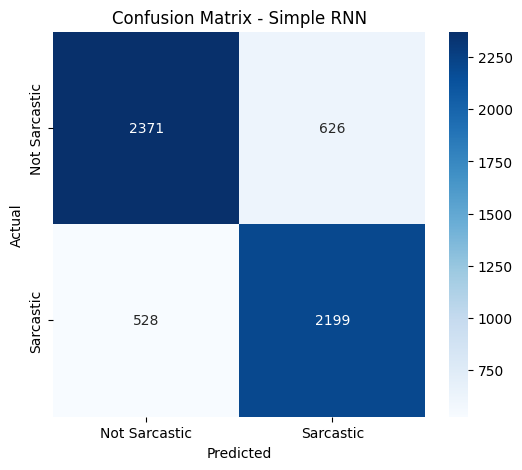

In [11]:
# --- Evaluate Simple RNN ---
y_pred_rnn = (model_rnn.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()

# Calculate metrics
accuracy_rnn = accuracy_score(y_test_final, y_pred_rnn)
print(f"\nSimple RNN Test Accuracy: {accuracy_rnn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_rnn, target_names=['Not Sarcastic', 'Sarcastic']))

# Confusion Matrix
cm_rnn = confusion_matrix(y_test_final, y_pred_rnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - Simple RNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

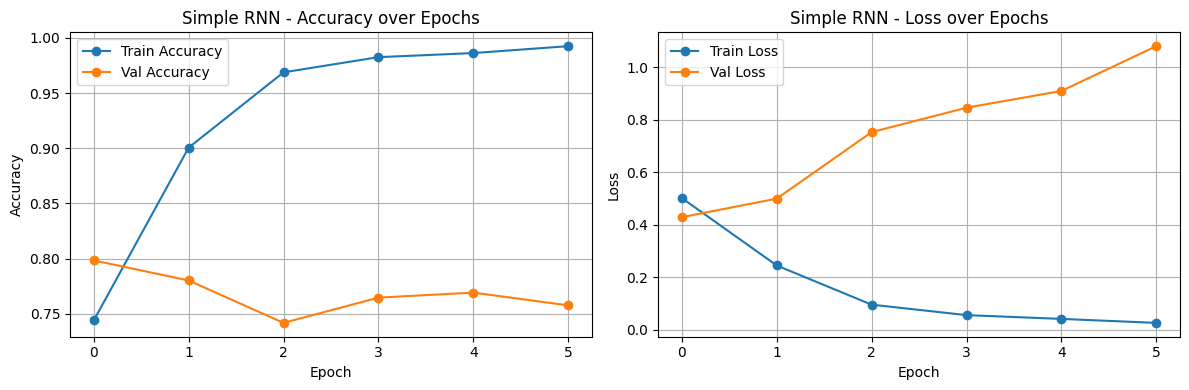

In [12]:
# --- Plot Training History for Simple RNN ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_rnn.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('Simple RNN - Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_rnn.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_rnn.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('Simple RNN - Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Model 2 - LSTM (Build and Train)
# ============================================================
# Build, compile, and train an LSTM model for
# sarcasm detection. LSTMs can better capture long-range
# dependencies compared to Simple RNNs.
# Architecture: Embedding -> LSTM -> Dropout -> Dense
# ============================================================

# --- Build LSTM Model ---
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, name='embedding'),
    LSTM(64, activation='tanh', name='lstm'),
    Dropout(0.5, name='dropout'),
    Dense(1, activation='sigmoid', bias_initializer=Zeros(), name='output')
])

# Explicitly build to resolve shapes
model_lstm.build(input_shape=(None, max_length))

# Compile the model
model_lstm.compile(optimizer=Adam(learning_rate=0.0005),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 128)        │     2,885,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,105 (11.20 MB)

 Trainable params: 2,935,105 (11.20 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Train LSTM ---
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

print("=" * 50)
print("TRAINING: LSTM")
print("=" * 50)

history_lstm = model_lstm.fit(
    X_train_pad, y_train_final,
    validation_data=(X_test_pad, y_test_final),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print("\n✅ LSTM Training Complete!")

TRAINING: LSTM
Epoch 1/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.7463 - loss: 0.5016 - val_accuracy: 0.7904 - val_loss: 0.4372
Epoch 2/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8595 - loss: 0.3257 - val_accuracy: 0.7926 - val_loss: 0.4497
Epoch 3/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9068 - loss: 0.2373 - val_accuracy: 0.7736 - val_loss: 0.5073
Epoch 4/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9412 - loss: 0.1621 - val_accuracy: 0.7689 - val_loss: 0.6270
Epoch 5/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9623 - loss: 0.1080 - val_accuracy: 0.7659 - val_loss: 0.8078
Epoch 6/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9627 - loss: 0.0998 - val_accuracy: 0.7617 - val_loss: 0.9335
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

✅ LSTM Training Complete!



LSTM Test Accuracy: 0.7904

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.82      0.77      0.79      2997
    Sarcastic       0.76      0.81      0.79      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



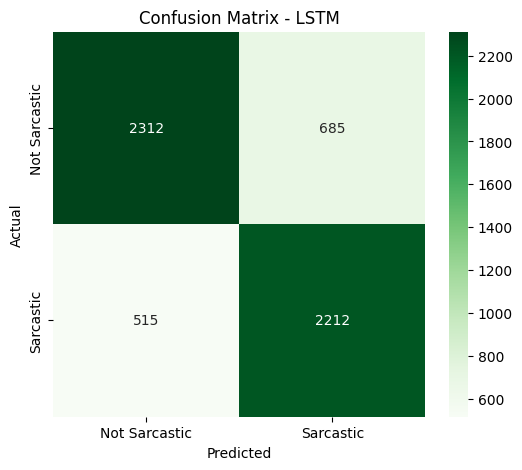

In [15]:
# --- Evaluate LSTM ---
y_pred_lstm = (model_lstm.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()

# Calculate metrics
accuracy_lstm = accuracy_score(y_test_final, y_pred_lstm)
print(f"\nLSTM Test Accuracy: {accuracy_lstm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_lstm, target_names=['Not Sarcastic', 'Sarcastic']))

# Confusion Matrix
cm_lstm = confusion_matrix(y_test_final, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - LSTM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

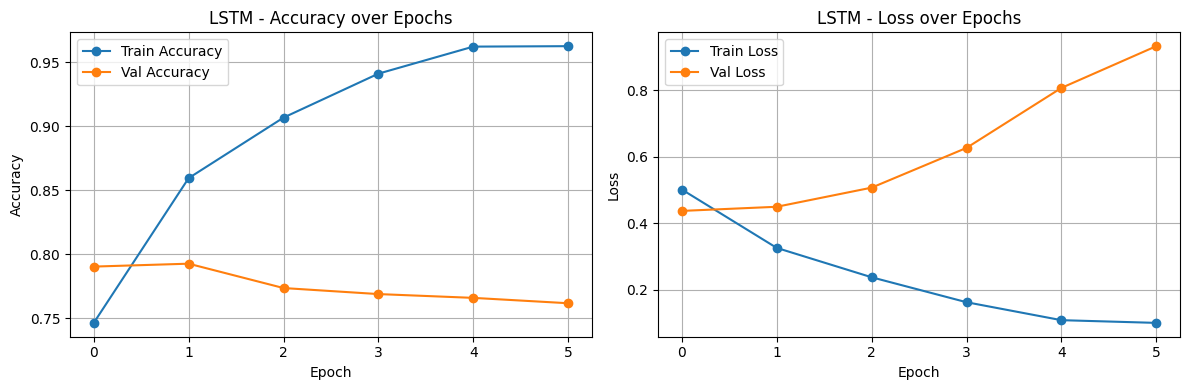

In [16]:
# --- Plot Training History for LSTM ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('LSTM - Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_lstm.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('LSTM - Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Load Pre-trained GloVe Embeddings
# ============================================================
# Load the pre-trained GloVe word embeddings
# (50-dimensional) and creates an embedding matrix that maps
# each token in our vocabulary to its pre-trained vector.
# ============================================================

print("Loading pre-trained GloVe embeddings (50D)...")
embedding_model = api.load('glove-wiki-gigaword-50')
print(f"✅ GloVe embeddings loaded!")
print(f"Embedding dimension: {embedding_model.vector_size}")

# Create the embedding matrix
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

found_words = 0
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found_words += 1

print(f"\nWords found in GloVe: {found_words}/{vocab_size-1} "
      f"({found_words/(vocab_size-1)*100:.1f}%)")

Loading pre-trained GloVe embeddings (50D)...
[==================================================] 100.0% 66.0/66.0MB downloaded
✅ GloVe embeddings loaded!
Embedding dimension: 50

Words found in GloVe: 19692/22543 (87.4%)


In [18]:
# ============================================================
# Model 3 - LSTM with GloVe Embeddings
# ============================================================
# Build and train an LSTM model initialized with
# pre-trained GloVe embeddings. The embeddings are set to
# trainable, allowing the model to fine-tune them.
# Architecture: GloVe Embedding -> LSTM -> Dropout -> Dense
# ============================================================

# --- Build LSTM + GloVe Model ---
model_lstm_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=True, name='glove_embedding'),
    LSTM(64, activation='tanh', name='lstm'),
    Dropout(0.5, name='dropout'),
    Dense(1, activation='sigmoid', bias_initializer=Zeros(), name='output')
])

# Explicitly build to resolve shapes
model_lstm_glove.build(input_shape=(None, max_length))

# Compile the model
model_lstm_glove.compile(optimizer=Adam(learning_rate=0.0005),
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

model_lstm_glove.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 11, 50)         │     1,127,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,156,705 (4.41 MB)

 Trainable params: 1,156,705 (4.41 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# --- Train LSTM + GloVe ---
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

print("=" * 50)
print("TRAINING: LSTM + GloVe")
print("=" * 50)

history_lstm_glove = model_lstm_glove.fit(
    X_train_pad, y_train_final,
    validation_data=(X_test_pad, y_test_final),
    epochs=30, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)
print("\n✅ LSTM + GloVe Training Complete!")

TRAINING: LSTM + GloVe
Epoch 1/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7120 - loss: 0.5541 - val_accuracy: 0.7738 - val_loss: 0.4776
Epoch 2/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - accuracy: 0.8128 - loss: 0.4054 - val_accuracy: 0.8042 - val_loss: 0.4187
Epoch 3/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8705 - loss: 0.3063 - val_accuracy: 0.8099 - val_loss: 0.4181
Epoch 4/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9011 - loss: 0.2460 - val_accuracy: 0.8050 - val_loss: 0.4547
Epoch 5/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9228 - loss: 0.2021 - val_accuracy: 0.7975 - val_loss: 0.5047
Epoch 6/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9376 - loss: 0.1683 - val_accuracy: 0.7923 - val_loss: 0.5422
Epoch 7/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9496 - loss: 0.1445 - val_accuracy: 0.7959 - val_loss: 0.5753
Epoch 8/30
716/716 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9583 - lo


LSTM + GloVe Test Accuracy: 0.8099

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.81      0.83      0.82      2997
    Sarcastic       0.81      0.79      0.80      2727

     accuracy                           0.81      5724
    macro avg       0.81      0.81      0.81      5724
 weighted avg       0.81      0.81      0.81      5724



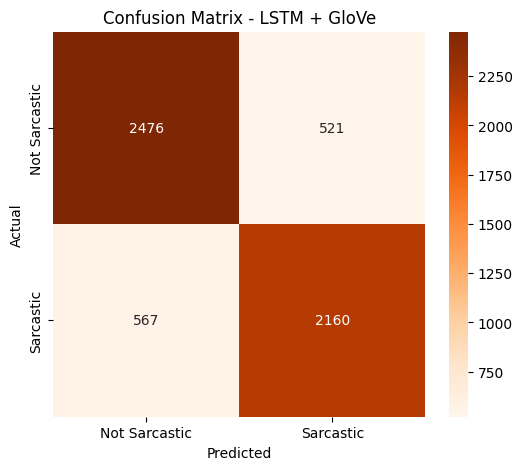

In [20]:
# --- Evaluate LSTM + GloVe ---
y_pred_glove = (model_lstm_glove.predict(X_test_pad, verbose=0) > 0.5).astype(int).flatten()

# Calculate metrics
accuracy_glove = accuracy_score(y_test_final, y_pred_glove)
print(f"\nLSTM + GloVe Test Accuracy: {accuracy_glove:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_glove, target_names=['Not Sarcastic', 'Sarcastic']))

# Confusion Matrix
cm_glove = confusion_matrix(y_test_final, y_pred_glove)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Sarcastic', 'Sarcastic'],
            yticklabels=['Not Sarcastic', 'Sarcastic'])
plt.title('Confusion Matrix - LSTM + GloVe')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

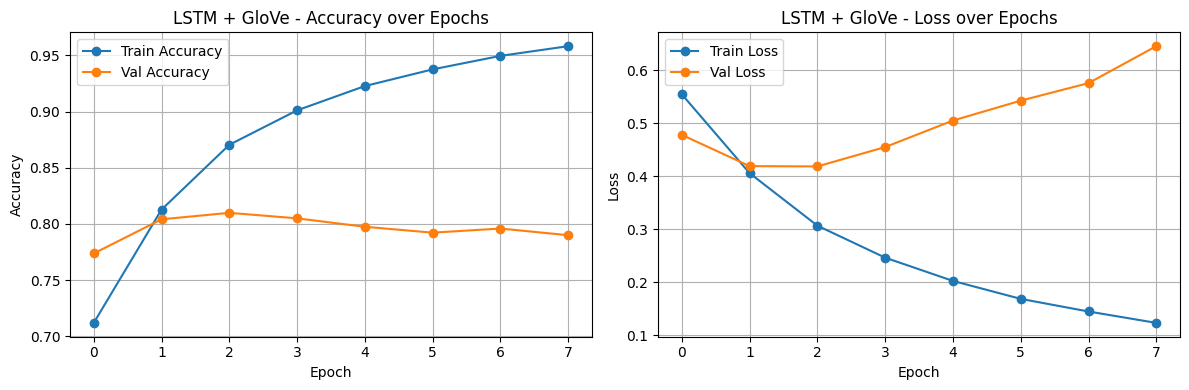

In [21]:
# --- Plot Training History for LSTM + GloVe ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm_glove.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history_lstm_glove.history['val_accuracy'], label='Val Accuracy', marker='o')
axes[0].set_title('LSTM + GloVe - Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_lstm_glove.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history_lstm_glove.history['val_loss'], label='Val Loss', marker='o')
axes[1].set_title('LSTM + GloVe - Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

MODEL PERFORMANCE COMPARISON
       Model  Accuracy  Precision   Recall  F1-Score
  Simple RNN  0.798393   0.799068 0.798393  0.798497
        LSTM  0.790356   0.791968 0.790356  0.790465
LSTM + GloVe  0.809923   0.809859 0.809923  0.809839


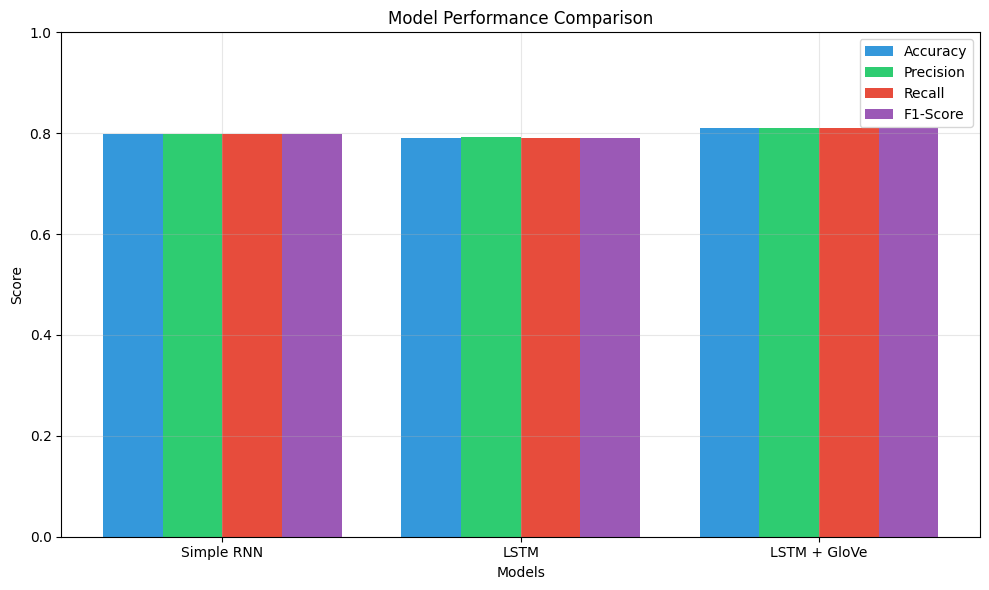

In [22]:
# ============================================================
# Model Performance Comparison
# ============================================================
# Create a comprehensive comparison of all three
# models using a summary table and a grouped bar chart.
# ============================================================

# Extract metrics from classification reports
report_rnn = classification_report(y_test_final, y_pred_rnn, output_dict=True)
report_lstm = classification_report(y_test_final, y_pred_lstm, output_dict=True)
report_glove = classification_report(y_test_final, y_pred_glove, output_dict=True)

# Build comparison summary table
data = {
    'Model': ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Accuracy': [report_rnn['accuracy'], report_lstm['accuracy'], report_glove['accuracy']],
    'Precision': [report_rnn['weighted avg']['precision'], report_lstm['weighted avg']['precision'], report_glove['weighted avg']['precision']],
    'Recall': [report_rnn['weighted avg']['recall'], report_lstm['weighted avg']['recall'], report_glove['weighted avg']['recall']],
    'F1-Score': [report_rnn['weighted avg']['f1-score'], report_lstm['weighted avg']['f1-score'], report_glove['weighted avg']['f1-score']]
}

comparison_df = pd.DataFrame(data)
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

# Grouped bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data['Model']))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, data[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(data['Model'])
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Error Analysis
# ============================================================
# Analyze misclassified examples from the best
# performing model to understand where it fails and why.
# ============================================================

# Find indices of misclassified examples for the GloVe model
misclassified_idx = np.where(y_pred_glove != y_test_final)[0]
print(f"Number of misclassified examples: {len(misclassified_idx)}")

# Display examples of false positives and false negatives
print("\n" + "=" * 60)
print("MISCLASSIFIED EXAMPLES ANALYSIS")
print("=" * 60)

fp_count = 0
fn_count = 0
for idx in misclassified_idx:
    if y_test_final[idx] == 0 and y_pred_glove[idx] == 1 and fp_count < 2:
        print(f"\n--- False Positive (Actual: Not Sarcastic, Predicted: Sarcastic) ---")
        print(f"Headline: {X_test.values[idx]}")
        print(f"Analysis: The model may have been misled by the formal or "
              f"sensational language, interpreting it as satirical.")
        fp_count += 1
    elif y_test_final[idx] == 1 and y_pred_glove[idx] == 0 and fn_count < 2:
        print(f"\n--- False Negative (Actual: Sarcastic, Predicted: Not Sarcastic) ---")
        print(f"Headline: {X_test.values[idx]}")
        print(f"Analysis: This sarcastic headline may use subtle, context-based "
              f"sarcasm that lacks explicit negative sentiment words, making "
              f"it hard for the model to detect.")
        fn_count += 1

Number of misclassified examples: 1088

MISCLASSIFIED EXAMPLES ANALYSIS

--- False Negative (Actual: Sarcastic, Predicted: Not Sarcastic) ---
Headline: group christie campaign deserter found forest
Analysis: This sarcastic headline may use subtle, context-based sarcasm that lacks explicit negative sentiment words, making it hard for the model to detect.

--- False Negative (Actual: Sarcastic, Predicted: Not Sarcastic) ---
Headline: democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
Analysis: This sarcastic headline may use subtle, context-based sarcasm that lacks explicit negative sentiment words, making it hard for the model to detect.

--- False Positive (Actual: Not Sarcastic, Predicted: Sarcastic) ---
Headline: prostitute female solo traveler
Analysis: The model may have been misled by the formal or sensational language, interpreting it as satirical.

--- False Positive (Actual: Not Sarcastic, Predicted: Sarcastic) ---
Headline:

In [24]:
# ============================================================
# GUI for Real-Time Prediction using Gradio
# ============================================================
# Builds a user-friendly web interface using Gradio
# that allows users to input a headline and get a real-time
# sarcasm prediction from the best performing model.
# ============================================================

# Select the best performing model
best_model = model_lstm_glove

def predict_sarcasm(headline):
    """
    Predict whether a headline is sarcastic or not.

    Args:
        headline (str): The news headline to classify.

    Returns:
        dict: Dictionary containing prediction label and confidence score.
    """
    # Clean the input text using the same preprocessing pipeline
    cleaned = clean_text(headline)

    # Convert to sequence and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    # Make prediction
    prob = best_model.predict(padded, verbose=0)[0][0]
    prediction = "Sarcastic 😏" if prob > 0.5 else "Not Sarcastic 📰"

    return {
        "Prediction": prediction,
        "Confidence": f"{prob:.2%}"
    }


def gradio_predict(headline):
    """Wrapper function for Gradio interface."""
    result = predict_sarcasm(headline)
    return f"{result['Prediction']}\nConfidence: {result['Confidence']}"


# Create Gradio interface
interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        label="Enter News Headline",
        placeholder="Type a headline here...",
        lines=3
    ),
    outputs=gr.Textbox(
        label="Prediction Result",
        lines=3
    ),
    title="🎭 Sarcasm Detection in News Headlines",
    description="""
    This AI model detects whether a news headline is **sarcastic** or **not sarcastic**.

    **Model:** LSTM with GloVe Embeddings
    **Dataset:** Sarcastic or Not Sarcastic Headlines

    **Examples of sarcastic headlines:**
    - "thirtysomething scientists unveil doomsday clock of hair loss"
    - "mother comes pretty close to using word 'streaming' correctly"

    **Examples of non-sarcastic headlines:**
    - "eat your veggies: 9 deliciously different recipes"
    - "5 ways to file your taxes with less stress"
    """,
    examples=[
        ["scientists discover that water is wet"],
        ["local man discovers that coffee helps him stay awake"],
        ["study finds that exercise is good for your health"],
        ["breaking news: politicians actually keep their promises this time"],
        ["new study reveals that sleep is important for well-being"],
        ["government announces plan to fix everything by next Tuesday"],
        ["thirtysomething scientists unveil doomsday clock of hair loss"],
        ["mother comes pretty close to using word 'streaming' correctly"],
        ["eat your veggies: 9 deliciously different recipes"],
        ["5 ways to file your taxes with less stress"]
    ],
    theme="soft"
)

# Launch the interface
interface.launch(share=True)

print("\n✅ Gradio Interface Launched!")
print("The GUI is now running and can be accessed via the public link above.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://27e018e319d882ac5a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ Gradio Interface Launched!
The GUI is now running and can be accessed via the public link above.
